# 30000 Spotify Songs

# IST 652

# Ben Dieck, Cooper Sorfleet, and Grace Mai

Our dataset, retrieved from Kaggle (https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs), consists of a list of about 30000 songs collected from the Spotify API and arranged in csv format. Exploration of this data, which spans multiple decades will reveal trends in the styles of music, as well as the specific song composition of popular hits. 

# Cleaning the Data

In [157]:
#import the following packages

import csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from difflib import get_close_matches
import os
import pymongo
from pymongo import MongoClient
import datetime

In [227]:
# Read in the CSV to a dataframe
def get_data(source_file):
    df = pd.read_csv(source_file)
    return df

# Remove extraneous columns, duplicate tracks, na values and add a column for album year
def transform_data(df):
    df=df.drop(['track_id','track_album_id','playlist_id'], axis=1)
    df=df.drop_duplicates('track_name')
    df['album_year']=df['track_album_release_date'].str.slice(0,4)
    df['album_year']=pd.to_numeric(df['album_year'])
    df=df.dropna(axis=0,how='any')
    return df

In [228]:
# Read in the information from the csv, change the spotify_clean parameter to wherever the file location is on your computer for the input csv.

spotify_data="spotify_songs.csv"
my_df=get_data(spotify_data)
my_df=transform_data(my_df)



# Exploratory Functions

In [229]:
# Create a report of songs with associated data, 
# this is a building block of the search_song function.

def create_song_report():
    song_report =  my_df[['track_name','track_artist', 'track_popularity', 'album_year','playlist_genre','energy']].rename(columns={'track_name': 'Title', 'track_artist' : 'Artist',
                                                                                                                                     'track_popularity': 'Popularity','album_year' : 'Release Year',
                                                                                                                                     'playlist_genre' : 'Genre' ,'energy' : 'Energy'})
    song_report = pd.DataFrame(song_report, columns=['Title','Artist','Popularity','Release Year','Genre','Energy'])
    #artist_report = artist_report.set_index('Title')

    return song_report

In [230]:
song_report = create_song_report()

In [231]:
# Retrieve an approximate match of a given search parameter.
# this is a building block of the search_song function.

def retrieve_song_data(artist_reportsong_report, key_value, threshold=0.6):
 
    # Check if the 'Title' column exists in the DataFrame
    if 'Title' not in song_report.columns:
        print("Error: Title column not assigned in dataframe.")
        return None

    # Search for the key value in the 'Title' column
    matches = get_close_matches(key_value, song_report['Title'], n=1, cutoff=threshold)

    # Check if any matches were found
    if matches:
        # Get the first matching record as a Pandas Series
        result = song_report[song_report['Title'] == matches[0]].iloc[0]
        return result
    else:
        print(f"No record found with a similar value to {key_value} in 'Title' column.")
        return None

In [232]:
#Search function to provide an individual song that is in the dataframe. 

def search_song():
    title=input("Enter song title: ")
    title=str(title)
    result_record = retrieve_song_data(song_report, title)

    if result_record is not None:
        print("Closest match to title found:")
        print(result_record)

In [233]:
# Make a copy of the original table, and put it in a dataframe. 
    
track_data = pd.DataFrame(my_df, columns=['track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 
                                          'track_album_release_date', 'album_year', 'playlist_name', 'songs_on_playlist', 'playlist_id',
                                          'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 
                                          'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'])



In [234]:
#Create a histogram of one of the column variables. Takes in the column variable as an input, but needs to be spelled correctly.
# Prints the histogram with labeling that reflects the input chosen.


def create_hist():
   
    var = input('Enter column name to analyze.')
    
    if var not in track_data.columns:
            print(f"Error: {var} not found in avilable DataFrame columns.")
            return None
# Check if the 'Title' column exists in the DataFrame
    if pd.api.types.is_numeric_dtype(track_data[var]):

        track_data[var].hist(bins = 75, color= '#92cf51', edgecolor = 'black')
        plt.xlabel(f"Measure of {var}.")
        plt.ylabel('Count of Tracks')
        plt.title(f"Analysis of {var}.")
        
    else:
        print(f"Error: {var} does not contain numeric data.")


In [235]:
# Create a copy of the dataframe that's clearly labeled.

attr_report =  pd.DataFrame(my_df, columns=['track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 
                                          'track_album_release_date', 'album_year', 'playlist_name', 'songs_on_playlist', 'playlist_id',
                                          'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 
                                          'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'])

In [236]:
# Subset it to include only records from useful years, might adjust later so I'll make this a function
# Enter the year that is the bottom of the range it'll bump out a dataframe that is a subset of the main df.
def attr_report_years(year):
    attr_report =  pd.DataFrame(my_df, columns=['track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 
                                          'track_album_release_date', 'album_year', 'playlist_name', 'songs_on_playlist', 'playlist_id',
                                          'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 
                                          'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'])
    if type(year)==int or type(year)==float:
        attr_report = attr_report[attr_report['album_year']>year]
    
    # If the above conditions aren't met, send this. 
    else:
        print("Non-numeric value supplied to the input.")
        
    return attr_report
    

In [237]:
# This returns a pivot of whatever variable in the set categorized by the sub-category and the years specified in the attr_report

def create_report_gen():
   
    var = input('Enter column name to analyze.')
    
    if var not in attr_report.columns:
            print(f"Error: {var} not found in avilable DataFrame columns.")
            return None
# Check if the 'Title' column exists in the DataFrame
    if type(var)==str:

        report = pd.pivot_table(attr_report, values=var, index=['album_year'],
                       columns=['playlist_genre'], aggfunc="mean")
        
    else:
        print(f"Error: {var} does not contain str data.")
        
    return report

#album_year

In [238]:
# This returns a pivot of whatever variable in the set categorized by the sub-category and the years specified in the attr_report

def create_report():
   
    var = input('Enter column name to analyze.')
    
    if var not in attr_report.columns:
            print(f"Error: {var} not found in available DataFrame columns.")
            return None
# Check if the 'Title' column exists in the DataFrame
    if type(var)==str:

        report = pd.pivot_table(attr_report, values=var, index=['album_year'],
                       columns=['playlist_subgenre'], aggfunc="mean")
        
    else:
        print(f"Error: {var} does not contain str data.")
        
    return report



In [271]:
# Export a csv file of a report made to the current working directory. 

def export_csv(data_frame):
    file_name = input('Enter the file save name: ')
    file_path = f"{file_name}.csv"
    file_directory = os.getcwd()

    # Check if the file already exists while giving the option to overwrite. 
    if os.path.exists(file_path):
        overwrite = input(f"The file '{file_path}' already exists. Do you want to overwrite it? (yes/no): ").lower()
        if overwrite != 'yes':
            print("Operation aborted. Choose a different filename.")
            return
   
    #Try catch language for a failed directory.
    try:
        data_frame.to_csv(file_path, index=False)
        print(f"CSV file '{file_path}' has been successfully written to the directory '{file_directory}'.")
    except Exception as e:
        print(f"Error: {e}. Failed to write the CSV file.")

In [240]:
#Write a dataframe to mongo specifying the DB name and the collection name

def df_to_mongo(dataframe):

    database = input('Specify database.')
    collection = input('Specify collection name.')
    try:
            # Connect to MongoDB
            client = MongoClient('localhost', 27017)
            existing_databases = client.list_database_names()

            # Check if the specified database already exists
            if database in existing_databases:
                print(f"Database '{database}' already exists. Writing to existing database.")
            else:
                print(f"Database '{database}' does not exist. Creating a new database.")

            db = client[database]
            collection = db[collection]

            # Convert the DataFrame to a dictionary
            data_dict = dataframe.to_dict(orient='records')

            # Insert the data into MongoDB
            collection.insert_many(data_dict)

            print("Data successfully saved to MongoDB.")

    except Exception as e:
        print(f"Error: {e}")

In [241]:
def plot_genre_popularity(data):
    genre_popularity = data.groupby('playlist_genre')['track_popularity'].mean().sort_values()
    plt.figure(figsize=(10, 6))
    sns.barplot(x=genre_popularity.values, y=genre_popularity.index)
    plt.title('Average Popularity of Songs by Genre')
    plt.xlabel('Average Popularity')
    plt.ylabel('Genre')
    plt.show()

In [242]:
#Group the artists into their genres by comparing track_artist to playlist_genre and get the average popularity

def group_artists_by_genre(df, features, popularity_col='track_popularity'):
    # Grouping and calculating mean for the specified features and popularity
    grouped = df.groupby(['track_artist', 'playlist_genre'])[features].mean()
    grouped['average_popularity'] = df.groupby(['track_artist', 'playlist_genre'])[popularity_col].mean()
    return grouped

In [243]:
#Selects most and least popular artists based on the quantile of average track popularity.

def get_most_popular_artists(grouped_df, quantile=0.90, popularity_col='average_popularity'):
    def filter_most_popular(x):
        return x[x[popularity_col] >= x[popularity_col].quantile(quantile)]

    most_popular = grouped_df.groupby('playlist_genre').apply(filter_most_popular)
    return most_popular

In [244]:
def get_least_popular_artists(grouped_df, quantile=0.90, popularity_col='average_popularity'):
    def filter_least_popular(x):
        return x[x[popularity_col] <= x[popularity_col].quantile(1 - quantile)]

    least_popular = grouped_df.groupby('playlist_genre').apply(filter_least_popular)
    return least_popular

In [245]:
#Plots comparison graphs for most and least popular artists across genres.

def plot_comparison_graphs(most_popular_df, least_popular_df, features, colors):
    mean_features_most_popular = most_popular_df.groupby('playlist_genre')[features].mean()
    mean_features_least_popular = least_popular_df.groupby('playlist_genre')[features].mean()

    fig, axes = plt.subplots(2, 1, figsize=(12, 12))

    mean_features_most_popular.plot(kind='bar', color=colors, ax=axes[0])
    axes[0].set_title('Musical Features of Most Popular Artists Across Genres')
    axes[0].set_ylabel('Mean Value')
    axes[0].legend()

    mean_features_least_popular.plot(kind='bar', color=colors, ax=axes[1])
    axes[1].set_title('Musical Features of Least Popular Artists Across Genres')
    axes[1].set_ylabel('Mean Value')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [246]:
#Plot a graph of an speechiness and popularity variables with a loudness being represented by the size of the plot points
def Three_var_plot(xvar, yvar, sizevar):
    try:
        xvar = my_df[xvar]
        yvar = my_df[yvar]
        sizevar = my_df[sizevar]
        
        plt.scatter(x=xvar.values, y=yvar.values, s=sizevar.values*200)
        plt.title("Speechiness and Loudness versus Popularity")
        plt.xlabel("Popularity")
        plt.ylabel("Speechiness")
        plt.text(50, 0.5,"Size of marker = Loudness")
        plt.ylim(0, 0.6)
        plt.show()
    except KeyError:
            print(f"Error: Listed variables not found in available DataFrame columns.")
            return None

In [247]:
#Calculate and Plot average speechiness by genre
def genre_avgspeech():
    genre_speech = my_df.groupby('playlist_genre')['speechiness'].mean().sort_values()
    print(genre_speech)
    xvar = genre_speech.index
    yvar = genre_speech.values
    plt.figure(figsize=(10, 6))    
    plt.scatter(x=xvar, y=yvar, c=yvar)
    plt.title("Average Speechiness by Genre")
    plt.xlabel("Genre")
    plt.ylabel("Speechiness")
    plt.colorbar()
    plt.show()

In [248]:
#Calculate and Plot average loudness by genre
def genre_avgloud():
    genre_loud = my_df.groupby('playlist_genre')['loudness'].mean().sort_values()
    print(genre_loud)
    xvar = genre_loud.index
    yvar = genre_loud.values
    plt.figure(figsize=(10, 6))    
    plt.scatter(x=xvar, y=yvar, c=yvar)
    plt.title("Average Loudness by Genre")
    plt.xlabel("Genre")
    plt.ylabel("loudness")
    plt.colorbar()
    plt.show()

# General Exploratory Analysis

In [249]:
#List of column names and number of observations

print(my_df.columns.tolist())

len(my_df)

['track_name', 'track_artist', 'track_popularity', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'album_year']


23449

In [250]:
# Searching for a specific song
search_song()

Enter song title: Christmas
Closest match to title found:
Title           This Christmas
Artist          Donny Hathaway
Popularity                  75
Release Year              1990
Genre                      r&b
Energy                   0.645
Name: 25761, dtype: object


Enter column name to analyze.danceability


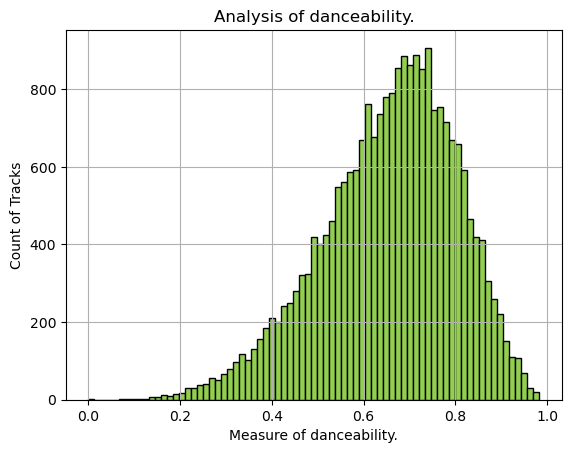

In [251]:
#Histogram of Danceability

create_hist()

Enter column name to analyze.energy


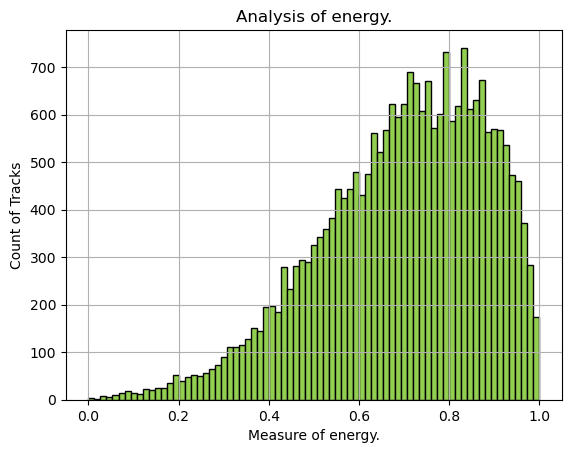

In [252]:
#Histogram of Energy
create_hist()

Generally speaking, large datasets are often found to follow a normal distribution. Danceability mirrors energy of songs very closely keeping to a normal distribution with a slight left skew, where energy levels have more skew to the left. Danceability, and energy are stylistic measurements, and so they follow a normal distribution. This pattern is likely because the input of the score relies on the majority's opinion of the artist. 

Enter column name to analyze.tempo


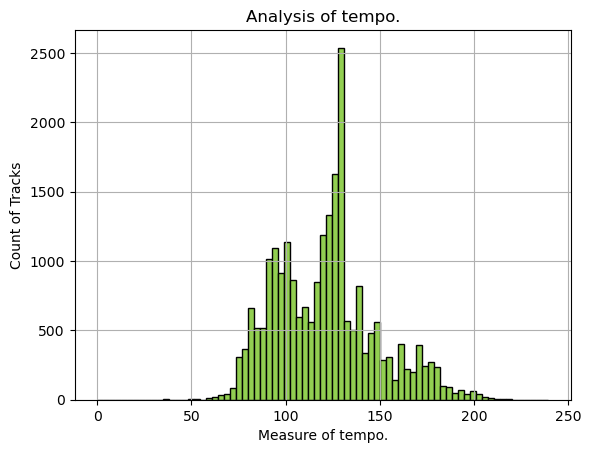

In [253]:
create_hist()

Tempo is interesting because it is a technical measurement, meaning you are measuring a behavior of a song produced by the artist. Unlike danceability and energy, it does not follow a normal distribution. Instead, this more follows the pattern of an artistic norm because it will often be determined by what is considered a best practice. As shown here, this is mostly found to be around 140 BPM. Not coincidentally, this is the similar to the highest pulse rate of a healthy human, which means one might expect this level in times of excitement. Utilizing this specific tempo, artists attempt to produce similar emotions and within listeners. 

# Hypothesis 1

Exploring the patterns of the variable danceability, we expect to find that Rock music has become less "danceable" over time in defence to pop and hip hop music. Furthermore, we believe there is an overall general trend of decreasing danceability measurements in more recently released songs than those released in the 1980s and 1990s. 

In [254]:
# Enter the year that is the bottom of the range.
    
attr_report = attr_report_years(1980)

In [255]:
#danceability

genre_plot = create_report()

Enter column name to analyze.danceability


In [256]:
genre_plot

playlist_subgenre,album rock,big room,classic rock,dance pop,electro house,electropop,gangster rap,hard rock,hip hop,hip pop,...,new jack swing,permanent wave,pop edm,post-teen pop,progressive electro house,reggaeton,southern hip hop,trap,tropical,urban contemporary
album_year,,,,,,,,,,,,,,,,,,,,,
1981,0.494200,NaN,0.539476,NaN,NaN,0.668333,NaN,0.480500,NaN,NaN,...,NaN,0.562556,NaN,0.436000,0.734000,NaN,0.730500,NaN,NaN,0.706000
1982,0.625118,NaN,0.673200,NaN,NaN,0.629250,NaN,0.551143,NaN,NaN,...,0.733000,0.626375,NaN,0.615000,0.892000,NaN,0.947000,NaN,NaN,0.842500
1983,0.602250,NaN,0.623727,NaN,NaN,0.646100,NaN,0.418222,NaN,NaN,...,NaN,0.598056,NaN,0.571500,0.758000,NaN,0.773000,NaN,NaN,0.654000
1984,0.626567,NaN,0.515083,NaN,NaN,0.625000,NaN,0.507333,NaN,0.664000,...,0.726667,0.539316,NaN,0.552400,NaN,NaN,0.919000,NaN,NaN,0.470000
1985,0.628211,NaN,0.609833,NaN,NaN,0.521800,NaN,0.440250,NaN,NaN,...,0.547500,0.568150,NaN,0.564000,NaN,NaN,0.797000,NaN,NaN,0.703500
1986,0.638056,NaN,0.457333,NaN,NaN,0.671625,NaN,0.581833,NaN,NaN,...,0.694833,0.551833,NaN,0.535500,NaN,NaN,0.775000,NaN,NaN,0.598000
1987,0.478500,NaN,0.594800,NaN,NaN,0.626333,NaN,0.412714,NaN,NaN,...,0.778556,0.595765,NaN,0.308333,NaN,NaN,0.727333,NaN,NaN,0.592500
1988,0.558000,NaN,0.548857,NaN,NaN,0.698714,0.811600,0.542000,NaN,NaN,...,0.748133,0.605071,NaN,0.431000,NaN,NaN,0.804500,NaN,NaN,0.563000
1989,0.506125,NaN,0.547500,NaN,NaN,0.637111,NaN,0.539333,NaN,NaN,...,0.714844,0.581429,NaN,NaN,NaN,NaN,0.853000,NaN,NaN,NaN


In [257]:
#danceability

genre_plot2 = create_report_gen()

Enter column name to analyze.danceability


In [258]:
genre_plot2

playlist_genre,edm,latin,pop,r&b,rap,rock
album_year,,,,,,
1981,0.734000,0.854000,0.635143,0.543500,0.730500,0.530833
1982,0.892000,0.755750,0.623143,0.787750,0.947000,0.624476
1983,0.758000,0.768500,0.633667,0.733200,0.773000,0.576466
1984,NaN,0.732000,0.604833,0.662800,0.919000,0.574172
1985,NaN,0.695200,0.567500,0.649000,0.797000,0.604494
1986,NaN,0.741500,0.644400,0.684412,0.775000,0.579571
1987,NaN,0.637750,0.580905,0.735667,0.727333,0.528426
1988,NaN,0.672846,0.665250,0.723571,0.805920,0.566795
1989,NaN,0.655500,0.637111,0.712455,0.853000,0.551121


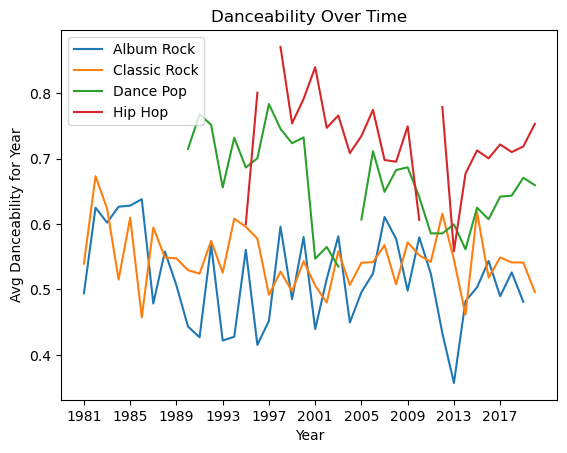

In [259]:
#Plot of danceability over time since 1980, shows that Rock genres are becoming less danceble in deference to pop and Hip Hop. 


# Plotting the lines
plt.plot(genre_plot.index, genre_plot['album rock'], label='Album Rock')
plt.plot(genre_plot.index, genre_plot['classic rock'], label='Classic Rock')
plt.plot(genre_plot.index, genre_plot['dance pop'], label='Dance Pop')
plt.plot(genre_plot.index, genre_plot['hip hop'], label='Hip Hop')

# Adding a legend
plt.legend()

# Adding labels and a title
plt.xlabel('Year')
plt.ylabel('Avg Danceability for Year')
plt.title('Danceability Over Time')
#Adjust the x axis labels
plt.xticks(genre_plot.index[::4])

# Display the plot
plt.show()

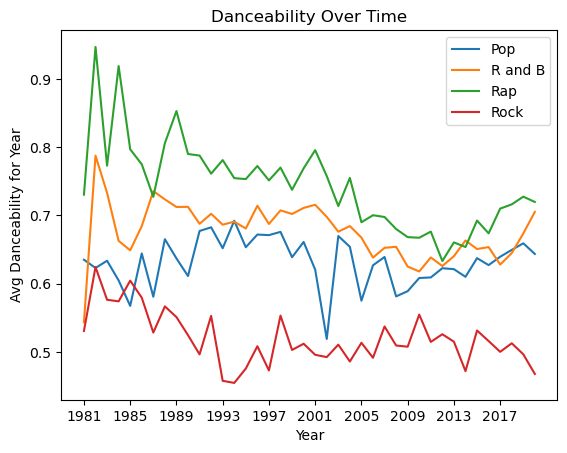

In [260]:
#Plot of danceability over time since 1980, shows that Rock genres are becoming less danceble in deference to Pop and RnB. 
#Strictly speaking however there is a trend of all music becoming less danceable over time. 

# Plotting the lines
plt.plot(genre_plot2.index, genre_plot2['pop'], label='Pop')
plt.plot(genre_plot2.index, genre_plot2['r&b'], label='R and B')
plt.plot(genre_plot2.index, genre_plot2['rap'], label='Rap')
plt.plot(genre_plot2.index, genre_plot2['rock'], label='Rock')

# Adding a legend
plt.legend()

# Adding labels and a title
plt.xlabel('Year')
plt.ylabel('Avg Danceability for Year')
plt.title('Danceability Over Time')
#Adjust the x axis labels
plt.xticks(genre_plot.index[::4])

# Display the plot
plt.show()

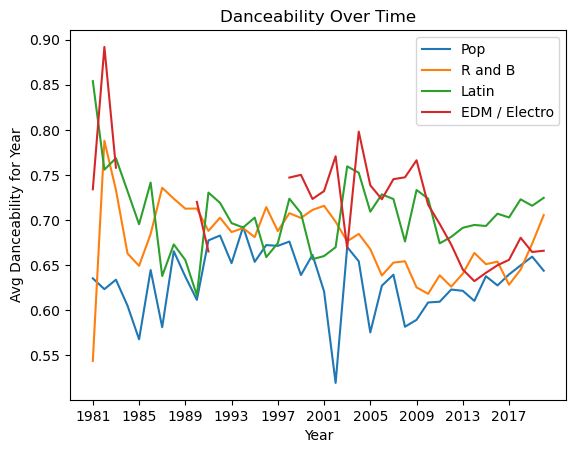

In [261]:
# Plotting the lines
plt.plot(genre_plot2.index, genre_plot2['pop'], label='Pop')
plt.plot(genre_plot2.index, genre_plot2['r&b'], label='R and B')
plt.plot(genre_plot2.index, genre_plot2['latin'], label='Latin')
plt.plot(genre_plot2.index, genre_plot2['edm'], label='EDM / Electro')

# Adding a legend
plt.legend()

# Adding labels and a title
plt.xlabel('Year')
plt.ylabel('Avg Danceability for Year')
plt.title('Danceability Over Time')
#Adjust the x axis labels
plt.xticks(genre_plot.index[::4])

# Display the plot
plt.show()

# Results Hypothesis 1:

In general, we noticed a trend within this data that music becomes less danceable as we progress towards 2020. This pattern was noticed within each genre category, but Latin music, and R and B were found to be more danceable than other categories. Though this category is based on a combination of various numerical data, such as tempo, rhythm stability, etc., an argument could still be made that this is a cultural preference for what is considered the "right" numbers for this measurement. 

# Hypothesis 2

Musical features such as danceability, energy, and valence significantly influence an artist's popularity within different music genres. Specifically, artists who are most popular within their respective genres tend to produce songs with higher danceability, energy, and valence compared to the least popular artists in the same genres.

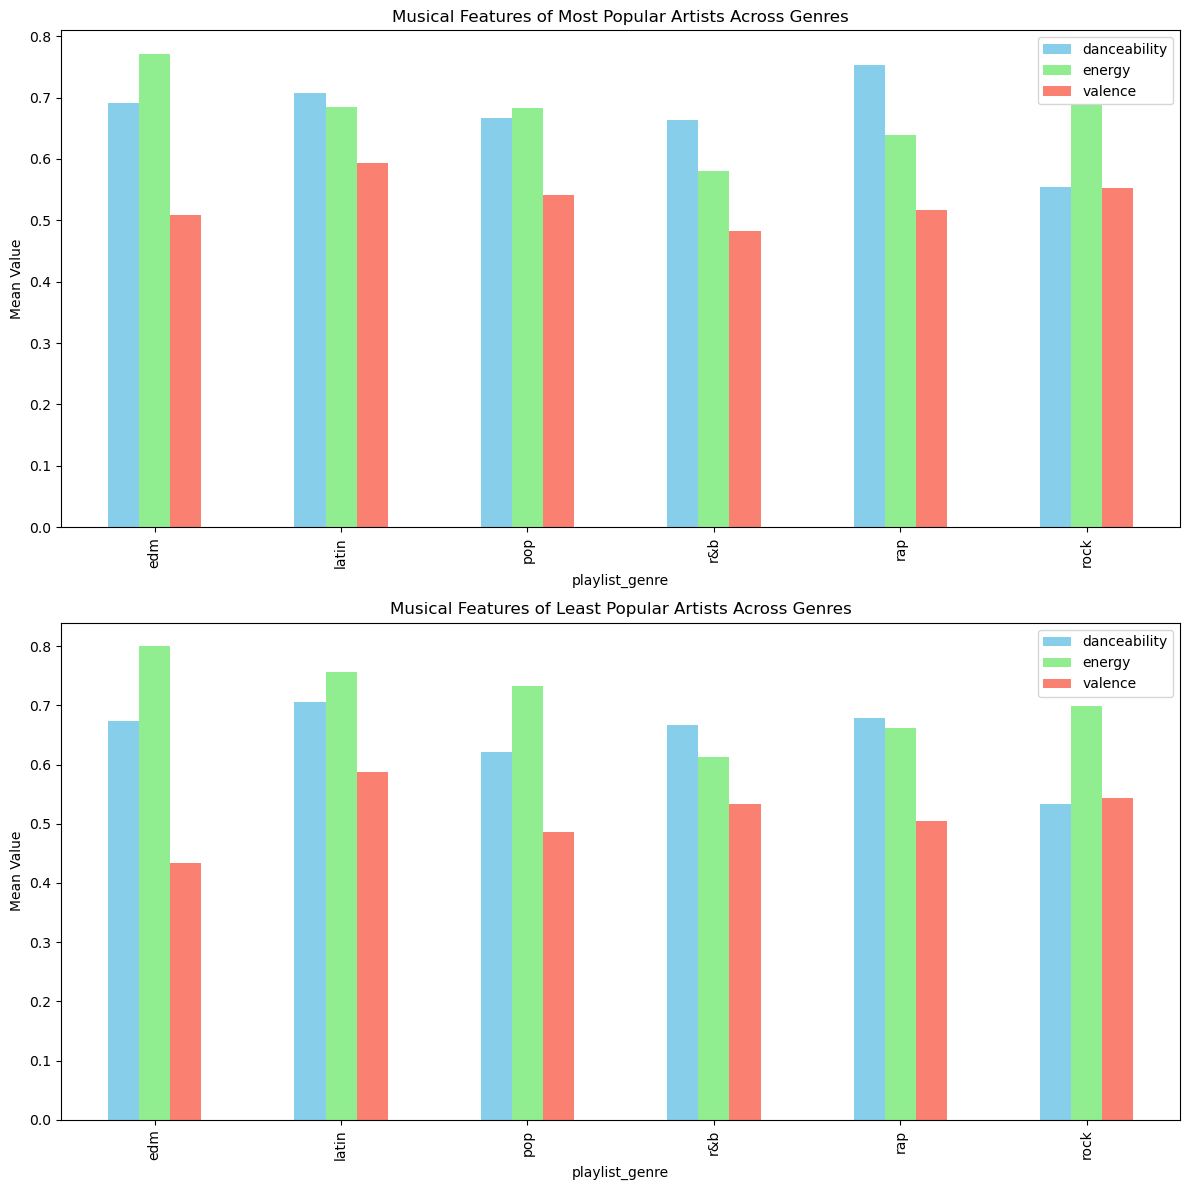

In [262]:
#Run the specified functions to create graphs comparing top 10% most popular artists across genres vs the least popular
features_to_analyze = ['danceability', 'energy', 'valence']
grouped_artists = group_artists_by_genre(my_df, features_to_analyze)
most_popular_artists = get_most_popular_artists(grouped_artists)
least_popular_artists = get_least_popular_artists(grouped_artists)
plot_comparison_graphs(most_popular_artists, least_popular_artists, features_to_analyze, ['skyblue', 'lightgreen', 'salmon'])

# Result Hypothesis 2

The results indicate that the most popular artists within various genres tend to produce songs with higher danceability, energy, and valence compared to their less popular counterparts. This pattern is consistent across multiple genres, suggesting a strong relationship between these musical features and an artist's popularity. Therefore, the hypothesis is supported by the analysis, highlighting the importance of these musical characteristics in popular music across different genres.

# Hypothesis 3

Adding lyrics to instrumental music allows the audience to connect with the music in a deeper way. Therefore, one would expect to see higher levels of "speechiness" within our dataset to be an indicator of higher popularity. However, if the track also shows high measurements in "loudness" one would expect the popularity to decrease. 

Text(0.5, 1.0, 'Track Speechiness versus Popularity ')

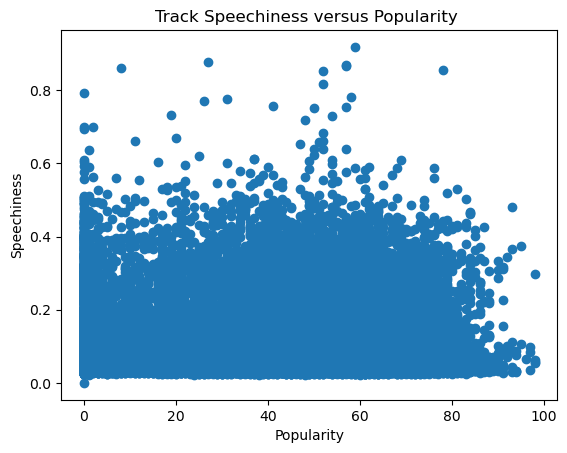

In [263]:
#Plot track speechiness versus popularity
plt.scatter(
    x=my_df['track_popularity'],
    y=my_df['speechiness']),

plt.xlabel('Popularity')
plt.ylabel('Speechiness')
plt.title('Track Speechiness versus Popularity ')

Text(0.5, 1.0, 'Track Loudness versus Popularity ')

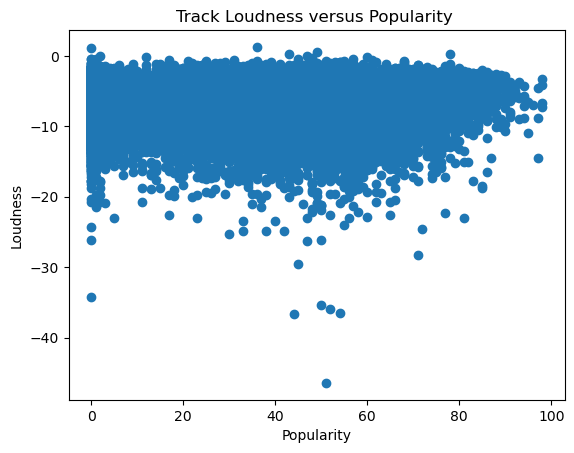

In [264]:
#Plot track loudness versus popularity
plt.scatter(
    x=my_df['track_popularity'],
    y=my_df['loudness'])

plt.xlabel('Popularity')
plt.ylabel('Loudness')
plt.title('Track Loudness versus Popularity ')

Due to the number of tracks, it is difficult to see the individual data points, but we are seeing most of the track information falling below the 0.5 measurement for speechiness, no matter the popularity scoring. In addition, we are seeing that most tracks gather between the 0 to -15 db range, but we see more variety into the lower decibels as popularity climbs past a score of 45. In fact, when considering the density of the grouping of values between 0 and 0.2 of speechiness and -5 and -10 of loudness, we can assume that most tracks are falling in those ranges.

playlist_genre
rock     0.058160
pop      0.074077
edm      0.088325
latin    0.101861
r&b      0.118565
rap      0.197700
Name: speechiness, dtype: float64


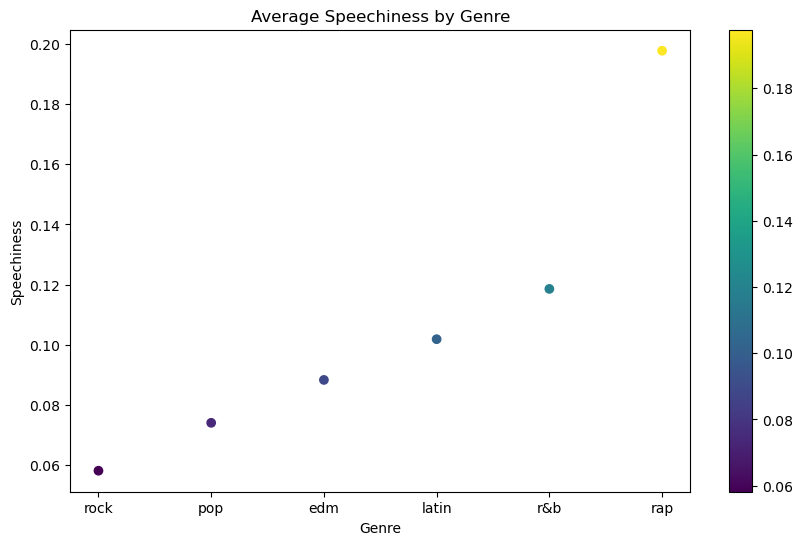

In [267]:
#Plotting average speech vs. genre
genre_avgspeech()

playlist_genre
r&b     -8.028591
rock    -7.620639
rap     -7.129948
latin   -6.538146
pop     -6.420466
edm     -5.545932
Name: loudness, dtype: float64


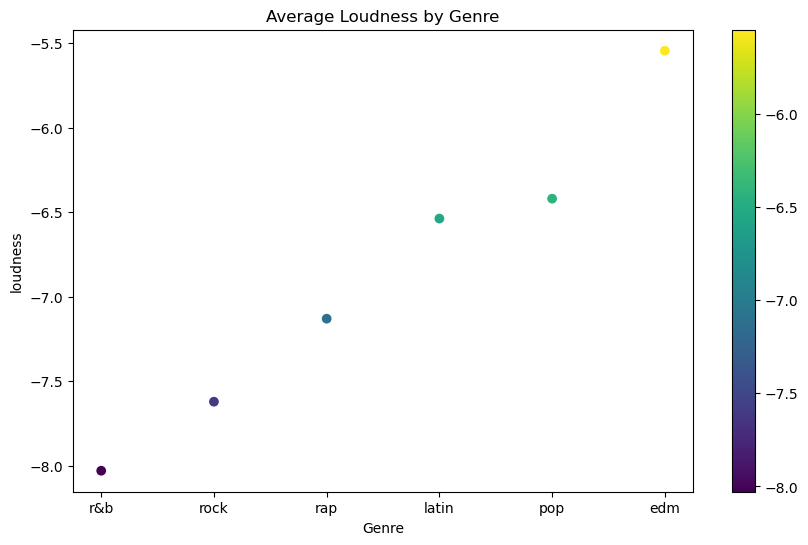

In [268]:
#Plotting average loudness vs. genre
genre_avgloud()

Unsurprisingly, we see that rap music has high levels of speech measurements, but what is surprising is the low levels of rock. The levels of loudness seem to average between the ranges of -6.0 and -8.0 decimals, which explains the large clusters of data we were seeing on the scatterplot above.  

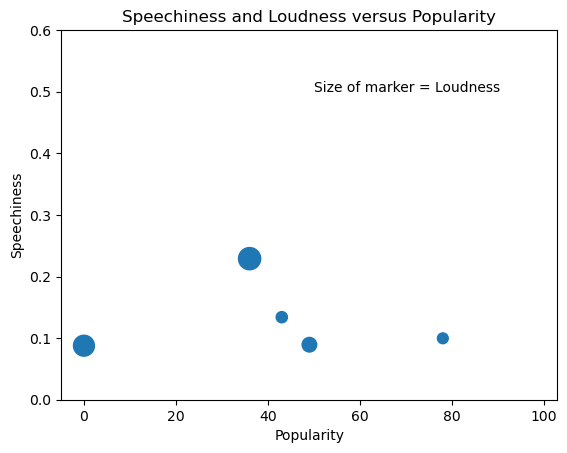

In [270]:
#Plot Speechiness and Loudness versus Popularity numbers
Three_var_plot('track_popularity', 'speechiness', 'loudness')

Based on the given plot which groups similar popularity levels, we see that the larger points, marking higher loudness levels, are measuring around 40 and 0 on the popularity scale. We also see that for the 0 popularity value, we see a level of less than 0.1 for speechiness. Interestingly, the highest measuring popularity scores are measuring at just over 0.1 speechiness levels, which was unexpected, and have a smaller point for loudness. 

# Result Hypothesis 3

While the data provided some interesting information to look into, it does not seem that levels off loudness and speechiness are appropriate variables to use when making inferences about popularity. When reviewing the dataset as a whole, the levels of speechiness and loudness seemed to remain consistent, no matter the achieved level of popularity. However, it was noticed that low levels of speechiness combined with higher levels of loudness showed indication of being less popular.

# Conclusion

Spanning several decades, the Spotify song dataset exhibits the evolution in human preferences regarding musical composition over time. In addition, the data reveals intriguing insights into the relationships between various musical attributes and the specific track's resulting popularity. It was found that variables such as danceability, energy, and valence have a more pronounced correlation with popularity. Specifically, tracks that are more danceable and energetic, as well as those that convey a more positive mood (higher valence), tend to experience greater popularity. This suggests that listeners prefer music that is uplifting and energizing.

On the other hand, the attributes of speechiness and loudness showed a less clear correlation with popularity. While high loudness is not necessarily a determinant of lower popularity, it was observed that tracks with lower measurements of spoken word (speechiness) combined with higher levels of loudness were generally less popular. This might indicate a listener preference for music that balances instrumental and vocal elements without being overwhelmingly loud or speech dominated.

Overall, these findings can provide valuable insights for music producers and artists in understanding listener preferences and trends in music consumption. However, it is important to acknowledge that music preference is highly subjective and influenced by numerous factors beyond the scope of this analysis. Therefore, while these correlations provide interesting trends, they do not represent definitive rules for musical success. 